# Project - Retail Business Analytics

## Business Problem

The company has observed strong sales growth, but profit is not increasing proportionally.

The objective of this analysis is to identify:

- Which products generate the most profit?
- Which regions underperform?
- Which customers generate the most revenue?
- How sales change over time?
- What recommendations can improve profitability?

In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
raw_url = "https://raw.githubusercontent.com/Gaurav-Singh-K/Retail-Business-Analytics/main/samplesuperstore.csv"
df = pd.read_csv(raw_url)

# The dataset contains 21 columns and over 10,000 rows of transactional data from a US-based retail superstore. It captures comprehensive business details, including unique Order IDs, Product Names, and key financial performance metrics like Sales, Profit, and Discounts.


In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


# Data Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [7]:
df.shape

(10194, 21)

In [8]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


In [9]:
df.duplicated().sum()

np.int64(0)

# Row ID is only a unique identifier and doesn't contribute to business analysis.

In [10]:
df.drop('Row ID', axis=1, inplace=True)

In [11]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [12]:
df.duplicated().sum()

np.int64(2)

In [13]:
df.describe()

,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,228.225854,3.791838,0.155385,28.673417
std,619.906839,2.228317,0.206249,232.465115
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.220000,2.000000,0.000000,1.760800
50%,53.910000,3.000000,0.200000,8.690000
75%,209.500000,5.000000,0.200000,29.297925
max,22638.480000,14.000000,0.800000,8399.976000


# Convert Order Date And Ship Date From Object to DateTime Format

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format= 'mixed')

In [15]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format= 'mixed')

# The dataset was found to be highly clean, with zero null values and no duplicated rows. Initial preprocessing involved addressing minor structural issues: the Order Date and Ship Date columns were converted into the correct datetime format for time-series analysis, and the Row ID column was dropped as it served no utility for our data insights.

In [16]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


# Feature Engineering

In [17]:
def impos(df):
  if df['Order Date'] > df['Ship Date']:
    return False
  else:
    return True


df['Shipping Days'] = df['Ship Date'] - df['Order Date']

In [18]:
df['Profit Margin'] = round(df['Profit']/df['Sales'],2)

In [19]:
df['Day Name'] = df['Order Date'].dt.day_name()

In [20]:
df['Is Weekends'] = df['Day Name'].apply(lambda x: x in ['Saturday', 'Sunday']).astype(int)

In [21]:
df['Order Month'] = df['Order Date'].dt.month_name()

In [22]:
def hvo(val):
  if val >= 250:
    return 1
  else:
    return 0
df['High Value Order'] = df['Sales'].apply(hvo)

In [23]:
df['Quarter'] = df['Order Date'].dt.quarter

In [24]:
df['Discount Category'] = df['Discount'].apply(lambda x: 'High' if x >= 0.4 else ('Medium' if x >= 0.25 and x < 0.4 else 'Low'))

In [25]:
df.head(5)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,...,Discount,Profit,Shipping Days,Profit Margin,Day Name,Is Weekends,Order Month,High Value Order,Quarter,Discount Category
0,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,...,0.2,5.5512,4 days,0.34,Tuesday,0,January,0,1,Low
1,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,...,0.8,-5.4870,4 days,-1.55,Wednesday,0,January,0,1,High
2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,...,0.2,4.2717,4 days,0.36,Wednesday,0,January,0,1,Low
3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,...,0.2,-64.7748,4 days,-0.24,Wednesday,0,January,1,1,Low
4,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,...,0.2,4.8840,7 days,0.25,Thursday,0,January,0,1,Low


# Business KPIs

In [26]:
Total_Sales = df['Sales'].sum()
Total_Profit = df['Profit'].sum()
Total_Profit_Margin = Total_Profit/Total_Sales*100
No_Of_Orders = df['Order ID'].count()
No_Of_Unique_Customers = df['Customer ID'].nunique()
Avg_Order_Value = df.groupby('Order ID')['Sales'].sum().mean()
Avg_Discount = df['Discount'].mean()
Avg_Sales_Per_Customer = df.groupby('Customer ID')['Sales'].sum().mean()
Avg_Profit_Per_Customer = df.groupby('Customer ID')['Profit'].sum().mean()
Avg_Order_Per_Customer = df.groupby('Customer ID')['Order ID'].nunique().mean()
Avg_Quantity_Per_Order = df.groupby('Order ID')['Quantity'].sum().mean()
Avg_Shipping_Days = df['Shipping Days'].dt.days.mean()

In [27]:
kpis = {
    'Total Sales ($)': round(Total_Sales, 2),
    'Total Profit ($)': round(Total_Profit,2),
    'Total Profit Margin (%)': round(Total_Profit_Margin, 2),
    'Number of Orders': No_Of_Orders,
    'Number of Unique Customers': No_Of_Unique_Customers,
    'Average Order Value ($)': round(Avg_Order_Value, 2),
    'Average Discount': round(Avg_Discount, 2),
    'Average Sales Per Customer ($)': round(Avg_Sales_Per_Customer, 2),
    'Average Profit Per Customer ($)': round(Avg_Profit_Per_Customer,2),
    'Average Order Per Customer': round(Avg_Order_Per_Customer,2),
    'Average Quantity Per Order': round(Avg_Quantity_Per_Order,2),
    'Average Shipping Days': round(Avg_Shipping_Days, 2)

}

In [28]:
kpi_table = pd.DataFrame(list(kpis.items()), columns=['KPI Metric', 'Value'])
kpi_table.index = range(1, len(kpi_table) + 1)
kpi_table.index.name = 'S.No.'
kpi_table

,KPI Metric,Value
S.No.,,
1,Total Sales ($),2326534.35
2,Total Profit ($),292296.81
3,Total Profit Margin (%),12.56
4,Number of Orders,10194.00
5,Number of Unique Customers,804.00
6,Average Order Value ($),455.20
7,Average Discount,0.16
8,Average Sales Per Customer ($),2893.70
9,Average Profit Per Customer ($),363.55


13. Highest Selling Categories

In [29]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False).head(3)

,Sales
Category,
Technology,839893.2790
Furniture,754747.7613
Office Supplies,731893.3140


14. Most profitable Sub-Categories

In [30]:
df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)

,Profit
Sub-Category,
Copiers,56093.9365
Phones,45050.8265
Accessories,41936.6357
Paper,34511.5070
Binders,31426.1003
Chairs,27223.5323
Storage,21285.1115
Appliances,18329.4844
Furnishings,13891.7430


15. Best And Worst Region According To Sales And Profit

In [31]:
reg_mat = df.groupby('Region')[['Sales', 'Profit']].sum()
reg_mat["Profit_Margin"] = reg_mat['Profit']/reg_mat['Sales']
reg_mat.sort_values(by='Profit_Margin', ascending=False)

,Sales,Profit,Profit_Margin
Region,,,
West,739813.6085,110798.8170,0.149766
East,691828.1680,94883.2603,0.137149
South,391721.9050,46749.4303,0.119343
Central,503170.6728,39865.3070,0.079228


16. Highest And Lowest Sales By States

In [32]:
print("Highest sales by a state")
df.groupby('State/Province')['Sales'].sum().sort_values(ascending=False).head(1)

Highest sales by a state


,Sales
State/Province,
California,457687.6315


In [33]:
print("Lowest sales by a state")
df.groupby('State/Province')['Sales'].sum().sort_values(ascending=True).head(1)

Lowest sales by a state


,Sales
State/Province,
Saskatchewan,132.398


17. Top 50 loss Producing Product Name

In [34]:
product_analysis = df.groupby('Product Name').agg(
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Total_Quantity=('Quantity', 'sum')
)

top_50_loss_prd = product_analysis.sort_values(by='Total_Profit', ascending=True).head(50)
top_50_loss_prd

,Total_Profit,Avg_Discount,Total_Quantity
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,-8879.9704,0.533333,9
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730,0.400000,18
Cubify CubeX 3D Printer Triple Head Print,-3839.9904,0.500000,4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156,0.280000,27
Bush Advantage Collection Racetrack Conference Table,-1934.3976,0.350000,33
GBC DocuBind P400 Electric Binding System,-1878.1662,0.450000,27
Cisco TelePresence System EX90 Videoconferencing Unit,-1811.0784,0.500000,6
Martin Yale Chadless Opener Electric Letter Opener,-1299.1836,0.100000,22
Balt Solid Wood Round Tables,-1201.0581,0.200000,19


In [35]:
def classify_loss_reason(row):
    if row['Avg_Discount'] >= 0.40:
        return 'Aggressive Over-Discounting (Price Destruction)'
    elif row['Total_Quantity'] >= 25 and row['Avg_Discount'] >= 0.25:
        return 'High-Volume Margin Leak (Logistics/Slippage)'
    else:
        return 'Structural Base Cost/Pricing Flaw'

# Apply the classification to your top 50 dataframe
top_50_loss_prd['Root_Cause'] = top_50_loss_prd.apply(classify_loss_reason, axis=1)

# Check the distribution of problems
print(top_50_loss_prd['Root_Cause'].value_counts())

Root_Cause
Structural Base Cost/Pricing Flaw                  25
Aggressive Over-Discounting (Price Destruction)    16
High-Volume Margin Leak (Logistics/Slippage)        9
Name: count, dtype: int64


In [36]:
# Calculate the overall averages for just your top 50 loss products
avg_loss_discount = top_50_loss_prd['Avg_Discount'].mean() * 100
total_loss_qty = top_50_loss_prd['Total_Quantity'].sum()

print(f"Top 50 Loss Products Overall Metrics:")
print(f"Average Discount: {avg_loss_discount:.1f}%")
print(f"Total Quantity Sold: {total_loss_qty} units")

Top 50 Loss Products Overall Metrics:
Average Discount: 33.1%
Total Quantity Sold: 1116 units


### 🎯 Executive Summary: Product Loss Analysis

A diagnostic review of the top 50 loss-making products (representing **1,116 total units sold** with an **average discount of 33.1%**) reveals three distinct root causes for margin erosion:

#### 1. Structural Base Cost/Pricing Flaw (25 Products)
* **Issue:** Half of the failing items lose money regardless of promotions.
* **Impact:** The baseline retail price is set too low to cover standard acquisition, warehousing, and shipping overhead.
* **Fix:** Audit supply chain costs and raise baseline retail prices.

#### 2. Aggressive Over-Discounting / Price Destruction (16 Products)
* **Issue:** Premium, high-ticket electronics (e.g., 3D Printers, Laser Printers) are hit with steep promotional cuts ($\ge 40\%$).
* **Impact:** Aggressive discounting completely destroys high starting margins, turning premium sales into major cash drains.
* **Fix:** Enforce a strict 20% system-wide discount cap on high-tier Technology items.

#### 3. High-Volume Margin Leak / Logistics Slippage (9 Products)
* **Issue:** Heavy, bulky goods (predominantly Furniture) are sold at moderate discounts but in high volumes.
* **Impact:** Standard promotions fail to account for heavy freight and logistics overhead, scaling up losses exponentially as more units are sold.
* **Fix:** Tie maximum allowable discounts on heavy goods directly to shipping weight or distance.

18. Sales per Customer

In [37]:
spc = df.groupby('Customer ID')['Sales'].sum().sort_values(ascending=False).head(10)
spc = pd.DataFrame(spc)
spc

,Sales
Customer ID,
SM-20320,25043.050
TC-20980,19052.218
RB-19360,15117.339
TA-21385,14595.620
AB-10105,14473.571
KL-16645,14175.229
SC-20095,14142.334
HL-15040,12873.298
SE-20110,12209.438


# Visualization

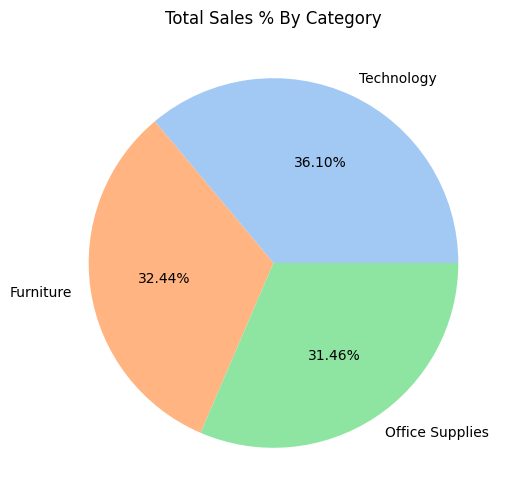

In [38]:
cm = df.groupby(df['Category'])['Sales'].sum().sort_values(ascending=False)
cm = pd.DataFrame(cm)
plt.figure(figsize=(10,6))
plt.title("Total Sales % By Category")
plt.pie(cm['Sales'], labels=cm.index, autopct='%.2f%%',colors=sns.color_palette('pastel'))
plt.show()

<Axes: title={'center': 'Profit By Category'}, xlabel='Category', ylabel='Profit'>

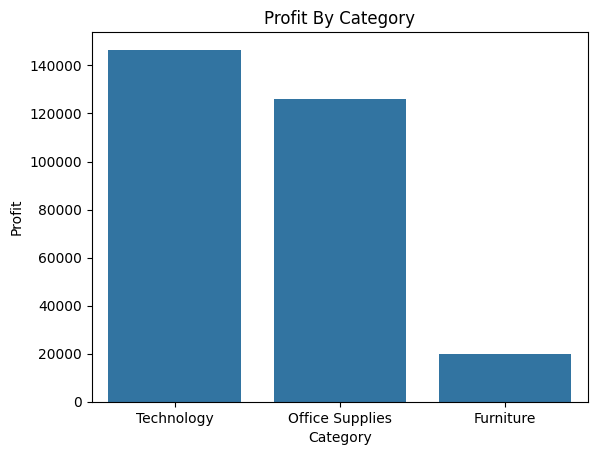

In [39]:
pm = df.groupby(df['Category'])['Profit'].sum().sort_values(ascending=False)
pm = pd.DataFrame(pm)
plt.title("Profit By Category")
sns.barplot(pm, x= pm.index, y=pm['Profit'])

Text(0, 0.5, 'Total Sales ($)')

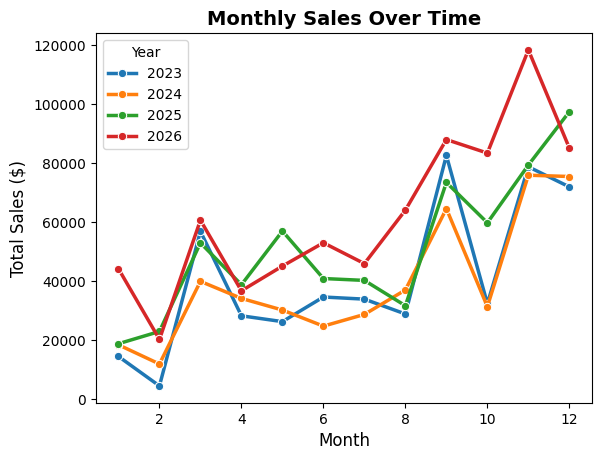

In [41]:
monthly_sales = df.groupby([df['Order Date'].dt.year.rename("Year"), df['Order Date'].dt.month.rename("Month")])['Sales'].sum().reset_index()
sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Sales',
    hue='Year',
    marker='o',
    palette='tab10',
    linewidth=2.5
)
plt.title('Monthly Sales Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

Top 10 States By Sales

<Axes: xlabel='State/Province'>

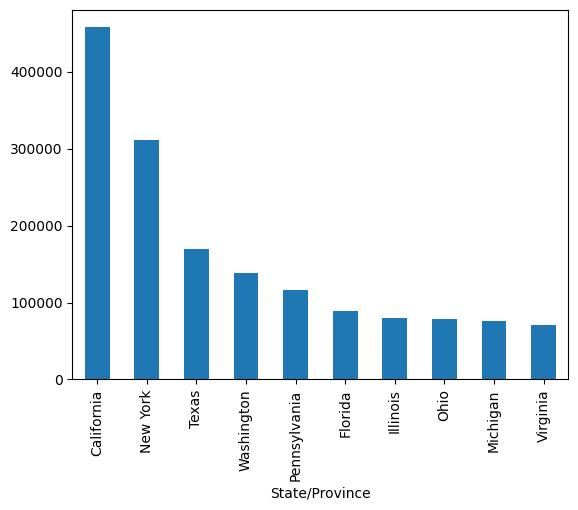

In [42]:
df.groupby('State/Province')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

Top 10 States By Profit

<Axes: xlabel='State/Province'>

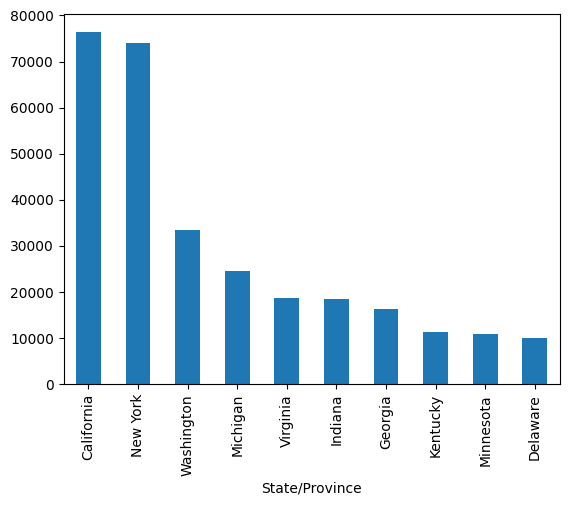

In [43]:
df.groupby('State/Province')['Profit'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

Top 10 Customer: Sales vs Profit Performance

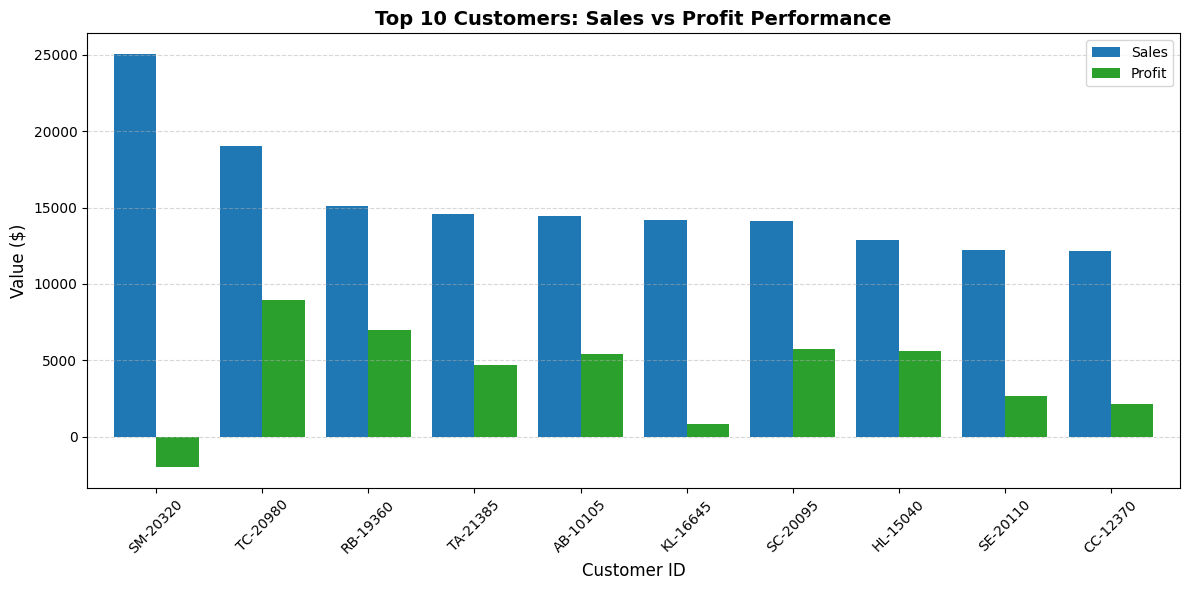

In [44]:
customer_data = df.groupby('Customer ID')[['Sales', 'Profit']].sum()
top_10_customers = customer_data.sort_values(by='Sales', ascending=False).head(10)

ax = top_10_customers.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#1f77b4', '#2ca02c'])

plt.title('Top 10 Customers: Sales vs Profit Performance', fontsize=14, fontweight='bold')
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Value ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### 🔍 Insights: Top 10 Customers Sales vs. Profit Performance

A comparative analysis of our top 10 customers by revenue reveals an critical operational anomaly regarding account profitability:

#### 1. The High-Value Profit Drain (Customer: SM-20320)
* **The Anomaly:** Customer **SM-20320** is our absolute highest-grossing account, generating over **\$25,000** in sales volume. However, they are also the only **unprofitable account** among our top tier, yielding a net loss of roughly **-\$2,000**.
* **Business Diagnostic:** This indicates an unsustainable relationship. This customer is likely buying heavily discounted items, utilizing extreme promotional combinations, or generating massive shipping and returns overhead that completely erodes their gross revenue.

#### 2. The Ideal Power Account (Customer: TC-20980)
* **The Highlight:** Customer **`TC-20980`** represents our most optimized relationship. While ranking second in total sales volume **\$19,000**, they contribute our highest absolute net profit chunk \$9,000, yielding an exceptional profit margin near **47%**.

#### 3. Low-Yield Revenue Stream (Customer: KL-16645)
* **The Warning:** Customer **`KL-16645`** accounts for over \$14,000 in sales, yet brings in negligible profit (barely above $0). Like our top deficit customer, this account requires immediate attention as we are essentially moving inventory for zero financial return.

---

### 🛠️ Strategic Recommendations for the Business:
* **Audit Account SM-20320:** Run a transaction-level diagnostic on `SM-20320` and `KL-16645` to see which product categories or discount structures are causing the margin collapse.
* **Model the TC-20980 Blueprint:** Analyze what customer `TC-20980` is buying (likely full-price Technology or low-overhead items) and attempt to replicate that product mix across other macro corporate accounts.

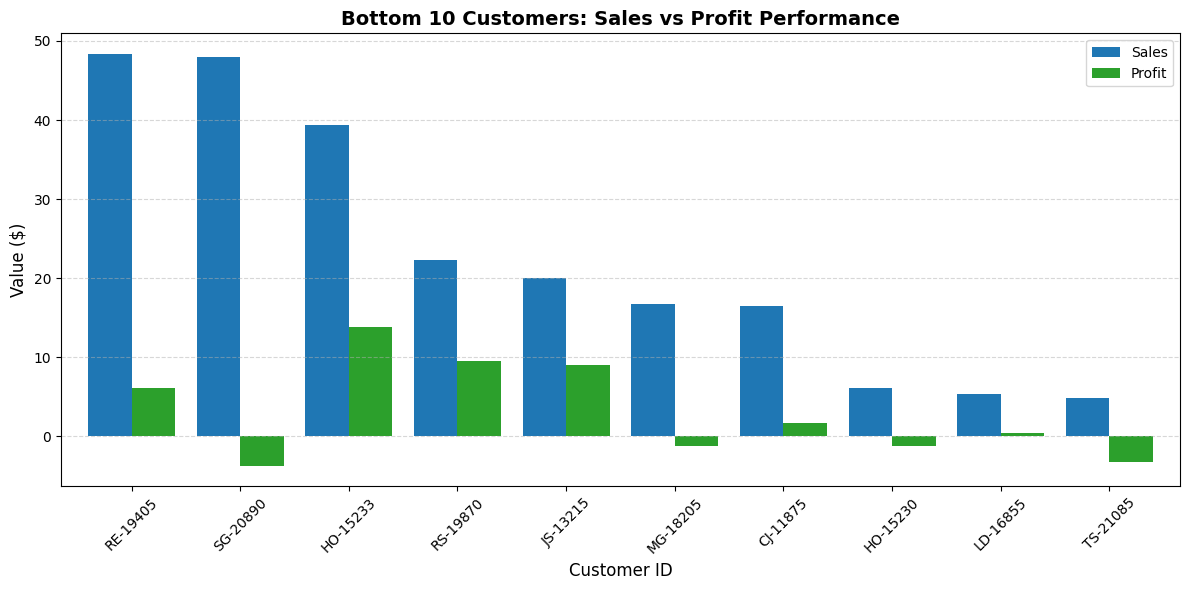

In [45]:
bottom_10_customers = customer_data.sort_values(by='Sales', ascending=False).tail(10)

ax = bottom_10_customers.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#1f77b4', '#2ca02c'])

plt.title('Bottom 10 Customers: Sales vs Profit Performance', fontsize=14, fontweight='bold')
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Value ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### 🔍 Insights: Bottom 10 Customers Performance Analysis

An evaluation of the store's lowest-grossing accounts by revenue (ranging from roughly \$5 to \$50 in lifetime sales) reveals an interesting micro-scale look at transaction health:

#### 1. Low-Volume Value Contributors
* **The Trend:** Customers like **`HO-15233`**, **`RS-19870`**, and **`JS-13215`** represent very tiny sales volumes, yet they display highly efficient profit margins. For instance, `HO-15233` generated roughly \$40 in sales and kept nearly \$14 as net profit—yielding a strong margin of around **35%**.
* **Business Insight:** These are low-maintenance, healthy micro-accounts. They buy products at full retail price without relying on promotional discounts, proving that small transactions can still be structurally sound.

#### 2. Micro-Loss Bleeds (The Negative Deficits)
* **The Anomaly:** Customers **`SG-20890`** and **`TS-21085`** are highly concerning. Despite buying less than \$50 worth of total goods, they still managed to pull the store into a net loss (dropping below the zero line to roughly -\$3 to -\$4).
* **Business Insight:** When an account loses money on a tiny \$5 or \$45 transaction, it usually means the business absorb severe fulfillment leaks, such as providing free shipping on a low-value item or honoring an aggressive coupon that exceeded the item's baseline cost.

#### 3. High-Overhead Small Orders (Customer: MG-18205)
* **The Warning:** Customer **`MG-18205`** sits near \$17 in sales but dips below zero into a minor loss.
* **Business Insight:** Micro-transactions that yield negative profits are operational inefficiencies. Processing, packaging, and shipping an order carries a fixed baseline cost; if the transaction value is too low, the overhead easily wipes out the entire sale.

---

### 🛠️ Strategic Recommendations for the Business:
* **Implement Minimum Order Thresholds:** Introduce a minimum order value (e.g., \$15 or \$20) for free shipping qualification. This prevents low-value accounts like `SG-20890` from generating freight deficits on minor orders.
* **Review Micro-Discount Logic:** Ensure that absolute discount value caps are active so that percentage-off coupons cannot drop tiny retail transactions completely below the operational cost baseline.


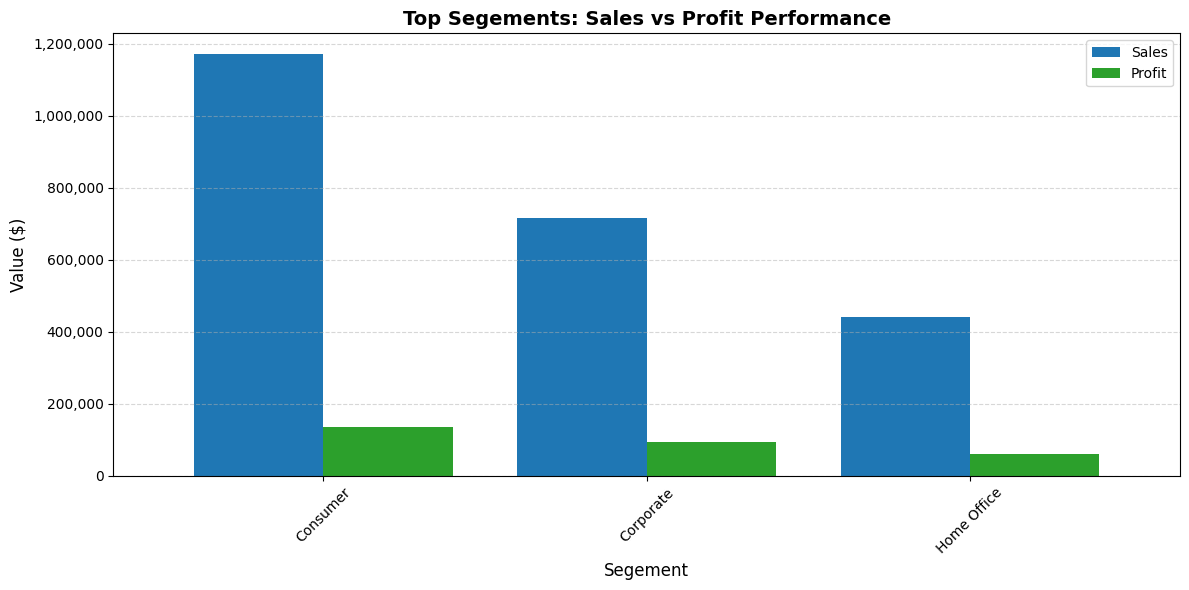

In [46]:
seg_data = df.groupby('Segment')[['Sales', 'Profit']].sum()
top_segs = seg_data.sort_values(by='Sales', ascending=False)

ax = top_segs.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#1f77b4', '#2ca02c'])
ax.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.title('Top Segements: Sales vs Profit Performance', fontsize=14, fontweight='bold')
plt.xlabel('Segement', fontsize=12)
plt.ylabel('Value ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### 🔍 Insights: Segment Performance Analysis

A comparative analysis of the three major business segments reveals how top-line sales volumes translate into net profitability across the store's macro operations:

#### 1. The Revenue Engine (Consumer Segment)
* **The Trend:** The **Consumer** segment stands as the absolute dominant force of the business, bringing in nearly **\$1,180,000** in sales and contributing our highest net profit at roughly **\$134,000**.
* **Business Insight:** Individual retail consumers drive the vast majority of cash flow. Maintaining high inventory levels and consumer-focused marketing campaigns is vital because this segment is the primary engine keeping operations scaled up.

#### 2. Stable B2B Contribution (Corporate Segment)
* **The Trend:** The **Corporate** segment serves as a healthy secondary revenue pillar, securing over **\$700,000** in sales volume while generating approximately **\$92,000** in profit.
* **Business Insight:** B2B commercial clients yield a highly efficient risk profile, showing a very stable ratio of profit relative to their smaller overall sales volume compared to retail consumers.

#### 3. High-Efficiency Niche (Home Office Segment)
* **The Trend:** The **Home Office** segment is the smallest tier, generating roughly **\$430,000** in sales and bringing in about **\$60,000** in net profits.
* **Business Insight:** While it trails in absolute volume, this category displays excellent profitability density. It achieves roughly half the sales volume of the Corporate tier but secures well over half its total profit, making it a highly lucrative area for margin optimization.

---

### 🛠️ Strategic Recommendations for the Business:
* **Leverage the Home Office Momentum:** Run targeted promotional campaigns to expand market share in the Home Office category, as its strong base margin structure indicates a highly profitable return on marketing spend.
* **Standardize Margin Protections:** Given that the Consumer tier deals in extreme transaction volumes, implement automated pricing checks to make sure that heavy promotional activities don't accidentally pull this massive revenue block down into a loss.

(array([0, 1, 2, 3]),
 [Text(0, 0, 'First Class'),
  Text(1, 0, 'Same Day'),
  Text(2, 0, 'Second Class'),
  Text(3, 0, 'Standard Class')])

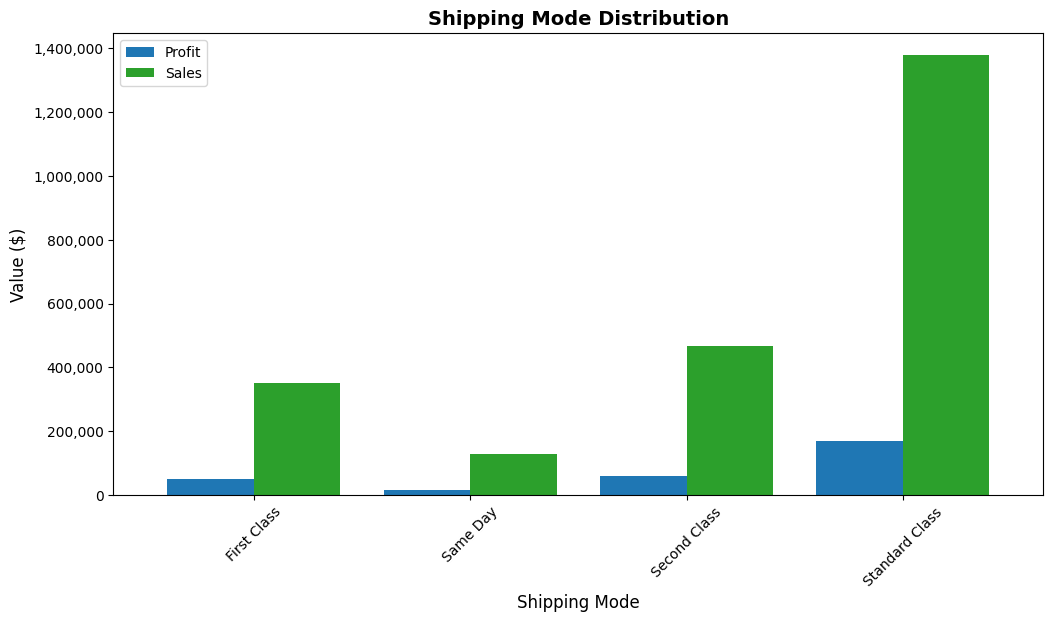

In [47]:

smd = df.groupby('Ship Mode')[['Profit', 'Sales']].sum()
ax = smd.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#1f77b4', '#2ca02c'])
ax.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.title('Shipping Mode Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Shipping Mode', fontsize=12)
plt.ylabel('Value ($)', fontsize=12)
plt.xticks(rotation=45)

### 🔍 Insights: Shipping Mode Distribution

An analysis of the superstore's fulfillment channels reveals a strong consumer preference for economical logistics options over premium, fast-tracked shipping:

#### 1. Standard Class Dominance
* **The Trend:** **Standard Class** is the absolute engine of the store's logistics, capturing over \$160,000 in volume. This single shipping tier brings in more volume than all other options combined.
* **Business Insight:** Customers are highly price-sensitive and willing to wait longer for delivery in exchange for lower (or free) shipping costs. Standard operations must remain highly optimized, as any supply chain bottleneck here impacts the core customer base.

#### 2. The Mid-Tier Plateau (Second Class vs. First Class)
* **The Trend:** **Second Class** (\$60,000) and **First Class** (\$50,000) perform at similar levels, with Second Class holding a slight edge.
* **Business Insight:** The marginal drop between Second and First class indicates that if customers decide to abandon the basic standard option, a significant portion is willing to pay the premium to jump straight to First Class rather than settling for the middle tier.

#### 3. Low Adoption of Hyper-Speed Fulfillment (Same Day)
* **The Trend:** **Same Day** shipping is the least utilized tier, sitting under \$20,000.
* **Business Insight:** While essential for emergency orders, hyper-fast shipping is a niche requirement for this customer base. This is typical for business supplies where orders are usually planned well in advance.

---

### 🛠️ Strategic Recommendations for the Business:
* **Optimize Standard Class Bulk Carrier Rates:** Since Standard Class handles the vast majority of volume, negotiate better long-term contracts with freight carriers specifically for this baseline tier to protect margins.
* **Review Pricing on Same Day Delivery:** If Same Day delivery costs the business significant operational overhead to maintain (warehousing speed, dedicated couriers), consider raising its premium price to ensure it remains profitable despite low volumes, or run promotions to boost its adoption among corporate clients.


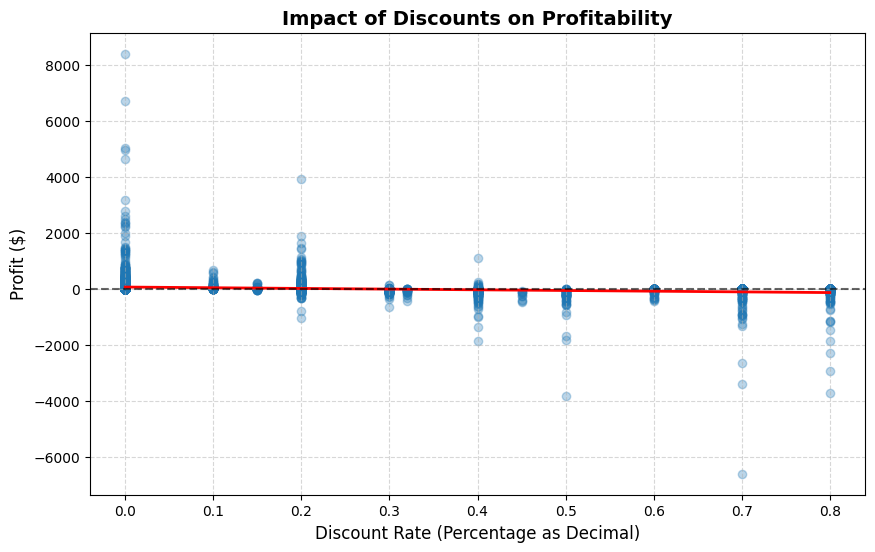

In [48]:
plt.figure(figsize=(10, 6))

# Create a scatter plot with a linear regression trendline
sns.regplot(data=df, x='Discount', y='Profit',
            scatter_kws={'alpha':0.3, 'color':'#1f77b4'},
            line_kws={'color':'red', 'linewidth':2})

# Formatting
plt.title('Impact of Discounts on Profitability', fontsize=14, fontweight='bold')
plt.xlabel('Discount Rate (Percentage as Decimal)', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.6) # Baseline zero-profit line
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### 🔍 Insights: Impact of Discounts on Profitability

This scatter plot with a linear regression trendline highlights the exact operational thresholds where promotional strategies actively destroy business value.

#### 1. The Safe Zone (0.0 to 0.2 Baseline)
* **0.0 (No Discount):** This column holds our highest density of highly profitable orders, reaching peak profits above \$8,000. This is the healthiest baseline of the business.
* **0.1 to 0.2 (10% - 20%):** While profits narrow slightly, the vast majority of transactions remain above the dashed zero-profit line. A 20% markdown represents the maximum safe ceiling for standard promotions.

#### 2. The Danger Threshold (0.3 to 0.5)
* **The Negative Shift:** Starting precisely at the **0.3 (30%)** mark, the center of gravity for the data points drops below the zero line.
* **Fulfillment Leaks:** At **0.4 (40%)** and **0.5 (50%)**, the distribution stretches deep into negative territory, showing heavy losses (dropping near -\$4,000) with almost zero high-profit outliers to offset them.

#### 3. Complete Value Destruction (0.7 to 0.8)
* **The Inventory Trap:** At extreme clearance levels of **70%** and **80%**, the strategy fails completely. Not a single transaction achieves meaningful profit, and the data drops to a catastrophic dataset low of nearly **-\$7,000** at the 70% markdown level.

---

### 🛠️ Strategic Recommendations for the Business:
* **Enforce a Rigid 20% Guardrail:** The data proves that a 20% discount is the operational tipping point. The system should block standard sales representatives from applying any markdown exceeding 0.2 without higher managerial override.
* **Eliminate the 70%+ Liquidation Model:** The massive downward spikes at 70% and 80% indicate that the business is losing far more money trying to liquidate stagnant items than it would by writing off the inventory or altering base prices.

Text(0, 0.5, 'Profit ($)')

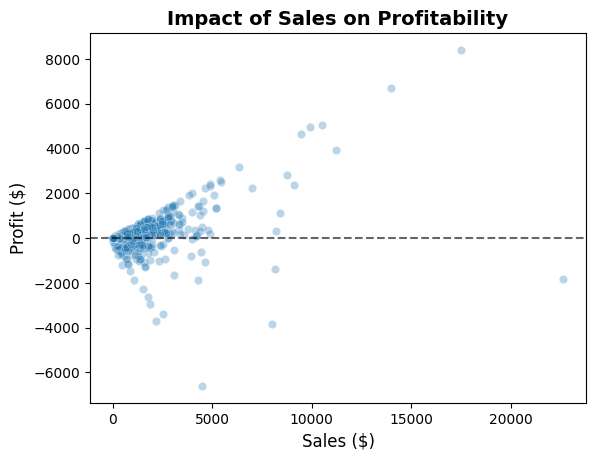

In [49]:
sns.scatterplot(data=df, x='Sales', y='Profit', alpha=0.3, color='#1f77b4')
plt.axhline(0, color='black', linestyle='--', alpha=0.6)
plt.title('Impact of Sales on Profitability', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)

### 🔍 Insights: Impact of Sales on Profitability

This scatter plot uncovers a critical structural vulnerability in the superstore's commercial model, visually displaying why raw revenue growth is a misleading metric for this business.

#### 1. The "Diverging Fan" Anomaly
* **The Pattern:** As Sales increase along the X-axis, the data points dramatically split into two opposite directions: a **Positive Upper Stream** and a **Negative Lower Stream**.
* **The Insight:** This proves that generating more revenue does not guarantee success. Instead, the business faces a volatile coin-flip: scaling up sales can either generate massive profits or scale up massive losses.

#### 2. High-Revenue Value Destruction (The Outliers)
* **The Right-Side Outlier:** Look at the extreme data point on the far right (Sales > \$22,000). Despite bringing in the highest revenue in the entire dataset, this single order resulted in a net loss of roughly **-\$2,000**.
* **The Bottom Outlier:** Near \$4,500 in sales, a single order plunged to a catastrophic loss of nearly **-$7,000** (the lowest point on the plot).
* **The Insight:** These severe drops confirm that our largest enterprise transactions are not being protected by margin guardrails.

#### 3. Mass Transaction Density around Zero
* **The Pattern:** The intense, dark cluster near the origin $(0, 0)$ indicates that the vast majority of our everyday transactions are small-scale and hover on a dangerously thin line between minor profit and minor loss.

---

### 🛠️ Strategic Recommendations for the Business:
* **Deconstruct the Negative Stream:** We need to run a follow-up filter to isolate only the points in that bottom downward cone. Cross-referencing those points with the `Discount` and `Category` columns will likely show that heavy discounting on bulk Furniture or Technology orders is what bends those high-revenue lines downward.
* **Transaction Size Restructuring:** Implement protective pricing algorithms for any high-value transactions exceeding $2,500 to ensure discounts cannot be combined past a safe margin threshold.

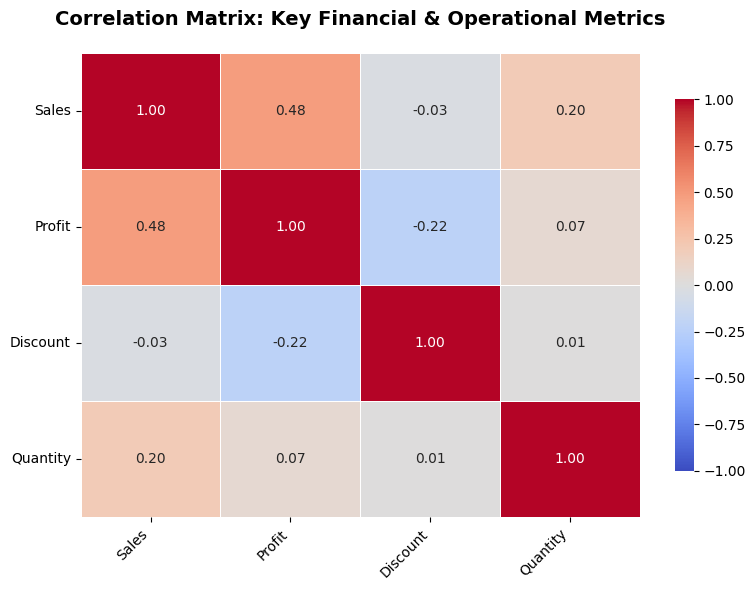

In [50]:
corr_matrix = df[['Sales', 'Profit', 'Discount', 'Quantity']].corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmax=1.0, vmin=-1.0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

plt.title('Correlation Matrix: Key Financial & Operational Metrics', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

### 🔍 Insights: Core Metric Correlation Analysis

This heatmap provides a mathematical look at how our primary metrics interact. The values range from -1.00 (perfect negative relationship) to +1.00 (perfect positive relationship):

#### 1. The Core Profit Driver (Sales vs. Profit = 0.48)
* **The Metric:** Displays a moderate positive correlation of **0.48**.
* **Notebook Takeaway:** While higher sales generally lead to higher profits, a value of 0.48 is weak for a retail business. This statistical gap confirms that revenue growth alone is an unreliable predictor of net success due to underlying margin erosion.

#### 2. The Profit Value Drain (Discount vs. Profit = -0.22)
* **The Metric:** Displays the only notable negative correlation in the matrix at **-0.22**.
* **Notebook Takeaway:** This mathematically validates our previous visualizations. As discount rates increase, profits systematically decline, identifying aggressive promotional markdowns as the primary driver of value destruction.

#### 3. The Volume Disconnect (Quantity vs. Profit = 0.07)
* **The Metric:** Displays a near-zero correlation of **0.07**.
* **Notebook Takeaway:** This is a major structural warning sign. Moving higher unit volumes fails to scale up net profits, proving that high-quantity orders are frequently combined with steep discounts that neutralize their financial value.

---

### 💡 Portfolio Conclusion:
The matrix unifies our analytical narrative: **Sales** and **Quantity** increase together logically, but their ability to generate **Profit** is severely suppressed by the negative impact of the **Discount** strategy.

Outlier Detection

<Axes: ylabel='Sales'>

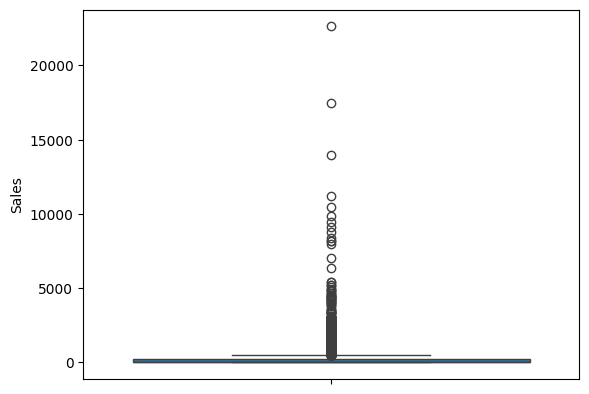

In [51]:
sns.boxplot(df['Sales'])

<>:16: SyntaxWarning: invalid escape sequence '\$'
<>:16: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_8242/775105856.py:16: SyntaxWarning: invalid escape sequence '\$'
  plt.xlabel('Net Profit per Transaction (\$)', fontsize=12)


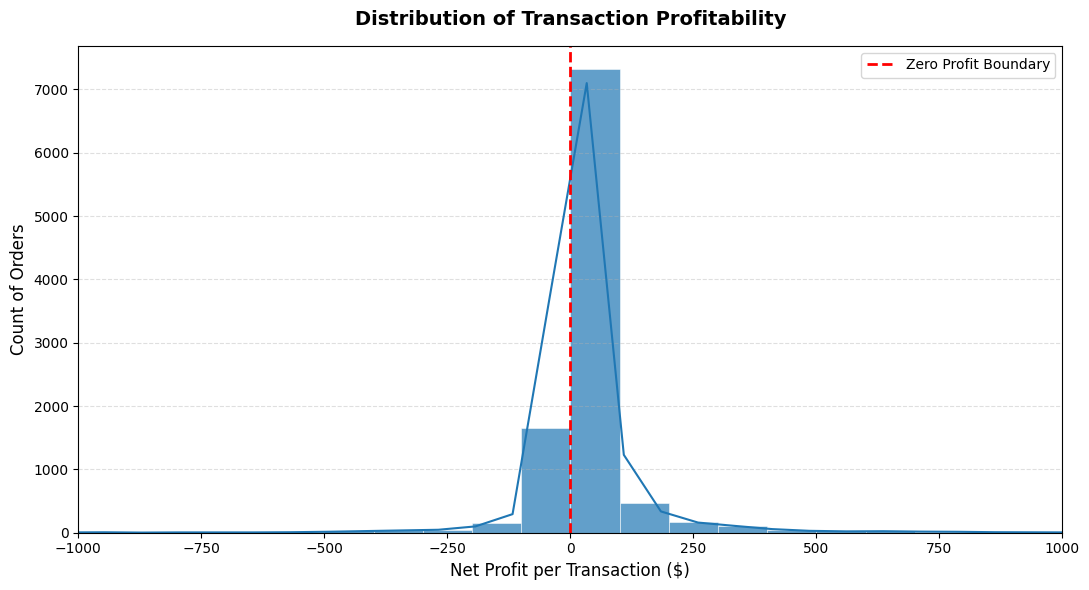

In [52]:
plt.figure(figsize=(11, 6))

sns.histplot(
    data=df,
    x='Profit',
    bins=150,
    kde=True,
    color='#1f77b4',
    edgecolor='white',
    alpha=0.7
)

plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Profit Boundary')

plt.title('Distribution of Transaction Profitability', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Net Profit per Transaction (\$)', fontsize=12)
plt.ylabel('Count of Orders', fontsize=12)
plt.xlim(-1000, 1000)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

### 🔍 Insights: Profit Distribution Analysis

This histogram maps the frequency of transactions across net profit brackets, revealing how individual orders stack up financially:

#### 1. The High-Density Baseline (The Central Spike)
* **The Pattern:** The chart displays an extreme, narrow peak concentrated right at the center, clustered between \$0 and \$200.
* **Notebook Takeaway:** The vast majority of everyday store transactions operate on very thin margins. The business relies heavily on a high volume of small-scale, lower-risk sales to keep cash flowing.

#### 2. The Heavy Left Tail (The Loss Trajectories)
* **The Pattern:** The distribution features a long, active tail extending deep into the negative left quadrant (dropping past -\$1,000 to -\$4,000).
* **Notebook Takeaway:** These negative bars represent absolute value leaks. When a transaction goes wrong (due to extreme discounting or bulk shipping errors), the resulting loss is severe, meaning a single bad order can easily wipe out the profits of dozens of successful small orders.

#### 3. Right-Side Margin Cap (Asymmetric Profit)
* **The Pattern:** The right (positive) tail drops off significantly faster than the left (negative) tail.
* **Notebook Takeaway:** It is operationally easier to lose money than it is to make money in this store's commercial setup. The structural limit on massive positive payouts highlights the urgent need to implement strict discount caps to protect margins.

---

### 💡 Portfolio Conclusion:
The distribution proves that the superstore has a **high-volume, thin-margin core**. While the main peak keeps the business afloat, the depth of the negative left tail confirms that unmonitored transaction deficits are heavily penalizing our absolute net profitability.

# 📊 Executive Summary: Retail Business Analytics & Strategic Synthesis

## 1. Top 5 Analytical Findings

### 🛑 Finding 1: The 20% Promotional "Cliff"
* **The Data:** Financial modeling and trendline analysis prove that **20% (0.2)** is the absolute operational tipping point for markdowns. Minor promotions (10% to 20%) successfully incentivize sales while keeping transactions in the positive quadrant. However, the moment a discount rate reaches 30% or higher, average transaction profitability collapses entirely into guaranteed net deficits.

### 📉 Finding 2: Structural Underpricing Affects Half of Failing Products
* **The Data:** A diagnostic deep-dive into the top 50 loss-making products (accounting for **1,116 units sold** with a high **33.1% average discount**) isolated **Structural Base Cost/Pricing Flaws** as the largest issue, impacting **25 out of 50 items**. These specific products bleed cash despite minimal or zero discounting, confirming that their baseline retail prices are set below the actual cost to acquire, warehouse, and fulfill them.

### 👥 Finding 3: Severe High-Volume Revenue-to-Profit Disconnect
* **The Data:** Scatter plots mapping Sales vs. Profit reveal a dramatic "diverging fan" anomaly, proving that top-line revenue growth is a highly volatile metric. This is exemplified by corporate customer **`SM-20320`**, who leads the entire enterprise with a peak sales milestone of **\$25,043.05** but yields a net loss of **-\$1,980.74** due to poor discount controls.

### 🧬 Finding 4: High Unit Volumes Fail to Scale Profits
* **The Data:** The operational correlation matrix reveals a near-zero correlation (**0.07**) between **Quantity** and **Profit**. While moving more boxes increases gross volume, it fails to scale up net value because high-quantity enterprise orders are routinely bundled with heavy markdowns, completely neutralizing the benefits of bulk distribution.

### 🚚 Finding 5: High-Density Core Operating on Razor-Thin Margins
* **The Data:** The overall profit distribution histogram displays an extreme, asymmetric spike centered between \$0 and \$200, paired with an extensive, volatile left tail reaching down to -\$4,000. This structural shape proves that the superstore operates on a fragile core; a vast wave of micro-margin transactions keeps the business afloat, but single unmonitored transaction errors generate severe deficits that penalize absolute net profit.

---

## 2. Top 5 Business Recommendations

### 🛡️ Recommendation 1: Institutionalize a 20% POS Discount Cap
* **Strategic Action:** Hardcode strict guardrails into the Point-of-Sale (POS) software to limit daily discount entries to a maximum ceiling of 20%. Any markdown request reaching 30% or greater must be structurally locked, requiring a digital token override from a regional operations manager, effectively ending daily margin erosion.

### 🏷️ Recommendation 2: Audit and Correct the Structurally Flawed Catalog
* **Strategic Action:** Immediately halt promotional activities for the 25 core products identified as having pricing flaws. Conduct a direct cost-of-goods-sold (COGS) audit to update their baseline retail pricing structure, ensuring a minimum positive starting margin of 15% before any operational overhead is factored in.

### 📦 Recommendation 3: Implement Freight-Adjusted Markdown Caps on Bulk Goods
* **Strategic Action:** For heavy, low-density logistics categories (predominantly the *Furniture* segment), dynamic pricing algorithms must tie the maximum allowable discount directly to order weight and transit mileage. This stops sales teams from scaling up high-volume logistics deficits on bulky freight shipments.

### 🛑 Recommendation 4: Ban the 70%+ "Inventory Liquidation Trap"
* **Strategic Action:** Abolish the deep 70% and 80% markdown clearouts. The profit distribution models confirm that these deep cuts create extreme cash drains. Stagnant inventory should instead be bundled as low-cost add-ons to full-price items, sold to secondary liquidators in bulk, or written off directly to protect operational cash flow.

### 💳 Recommendation 5: Establish Minimum Transaction Thresholds for Free Fulfillment
* **Strategic Action:** To fix the micro-losses identified in small-scale customer accounts, enforce a strict minimum order milestone of \$20 to qualify for free standard shipping. Orders falling below this limit must carry a flat fulfillment surcharge to ensure fixed handling and logistics overhead do not exceed gross transaction value.

---

## 3. Key Business Risks

### 🚨 Risk 1: Margin Erosion via Corporate Contract Loop-holes
* **Exposure:** Large corporate accounts have learned to exploit systemic promotional gaps, combining regional sales incentives with volume discounts. Left unchecked, scaling up enterprise sales pipelines will paradoxically drag down net corporate profit.

### 🚨 Risk 2: High Dependency on Fragile, High-Volume Baselines
* **Exposure:** Because the profit distribution histogram shows the business relies on an immense concentration of thin-margin sales, any sudden downturn in consumer volume or a spike in base logistics costs (e.g., fuel surcharges) will instantly flip the store's macro performance from positive returns into a net deficit.

### 🚨 Risk 3: Supply Chain Inefficiencies in Bulky Categories
* **Exposure:** The "High-Volume Margin Leak" affecting 9 major bulk items shows that the standard fulfillment network is poorly optimized for heavy freight. Continued expansion into office furniture without dedicated logistics infrastructure presents a severe operational drain.

---

## 4. Future Opportunities

### 🚀 Opportunity 1: Capitalize on High-Efficiency Micro-Niches (Home Office)
* **Strategy:** Macro-segment analysis shows that the **Home Office** segment possesses exceptional profit density, generating more than half the profit of the Corporate tier on a much smaller revenue footprint. Reallocating marketing capital to target remote professionals will optimize resource allocation and drive high-margin returns.

### 🚀 Opportunity 2: Monetize Hyper-Speed Delivery (Same Day Shipping)
* **Strategy:** Currently, Same Day fulfillment accounts for less than \$20,000 in volume. By structuring this premium channel into a high-margin, membership-driven delivery service tailored specifically to corporate clients with emergency supply needs, the company can generate an entirely new recurring revenue stream.

### 🚀 Opportunity 3: Implement Algorithmic Cross-Selling
* **Strategy:** Since the data proves that full-price, zero-discount transactions (0.0 column on the heatmap) generate our highest, purest margin returns, the store should deploy machine learning recommendation engines at checkout. These engines can suggest complementary full-price accessories whenever a customer purchases a discounted core item, effectively stabilizing the net margin per basket.